In [43]:
# yfinance를 이용한 삼성전자 주가 데이터 수집
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
# 삼성전자 티거 (005930.KS: 한국 주식, SMCI: 미국 주식
ticker = "005930.KS"
start_date = "2020-01-01"
end_date = "2025-01-01"

# 데이터 다운로드
df = yf.download(ticker, start=start_date, end=end_date)

# 데이터 확인
print(df.head())
print(df.tail())
print(df.info())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open    Volume
Ticker         005930.KS     005930.KS     005930.KS     005930.KS 005930.KS
Date                                                                        
2020-01-02  48208.378906  48907.051064  48033.710867  48470.380966  12993228
2020-01-03  48470.394531  49431.069017  47946.390266  48907.064752  15422255
2020-01-06  48470.394531  48557.728575  47684.388133  47946.390266  10278951
2020-01-07  48732.394531  49256.398774  48557.726450  48645.060491  10009778
2020-01-08  49605.742188  50129.746506  48819.735709  49081.737869  23501171
Price              Close          High           Low          Open    Volume
Ticker         005930.KS     005930.KS     005930.KS     005930.KS 005930.KS
Date                                                                        
2024-12-23  52823.835938  53317.516647  52626.363654  52725.099796  13672650
2024-12-24  53712.460938  53811.197079  52922.571806  53021.307947  11634677

<function matplotlib.pyplot.show(close=None, block=None)>

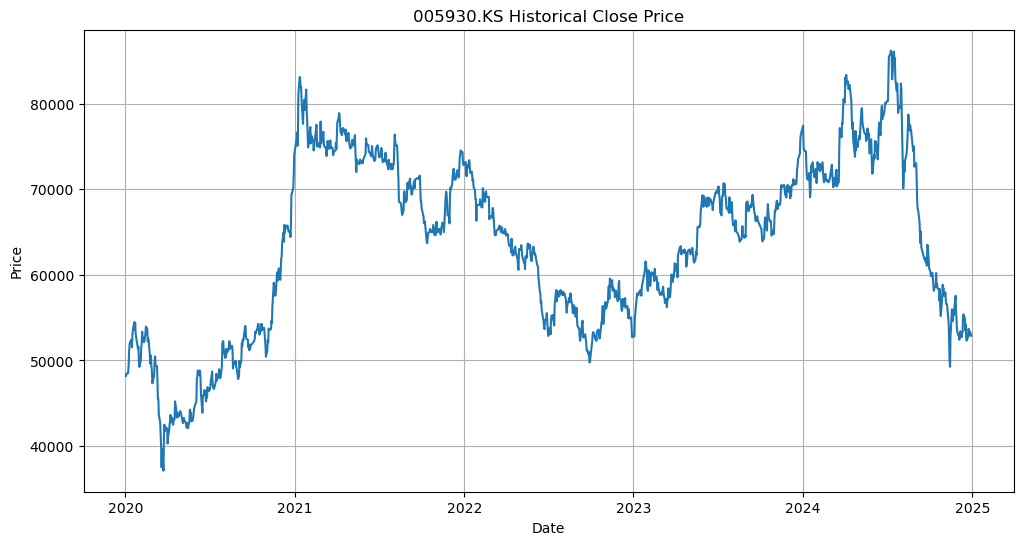

In [45]:
# 종가(Close) 시각화
plt.figure(figsize=(12, 6)) # 가로 12, 세로 6
plt.plot(df['Close'])
plt.title(f'{ticker} Historical Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show

In [46]:
# 결측치 확인
df.isnull().sum()

Price   Ticker   
Close   005930.KS    0
High    005930.KS    0
Low     005930.KS    0
Open    005930.KS    0
Volume  005930.KS    0
dtype: int64

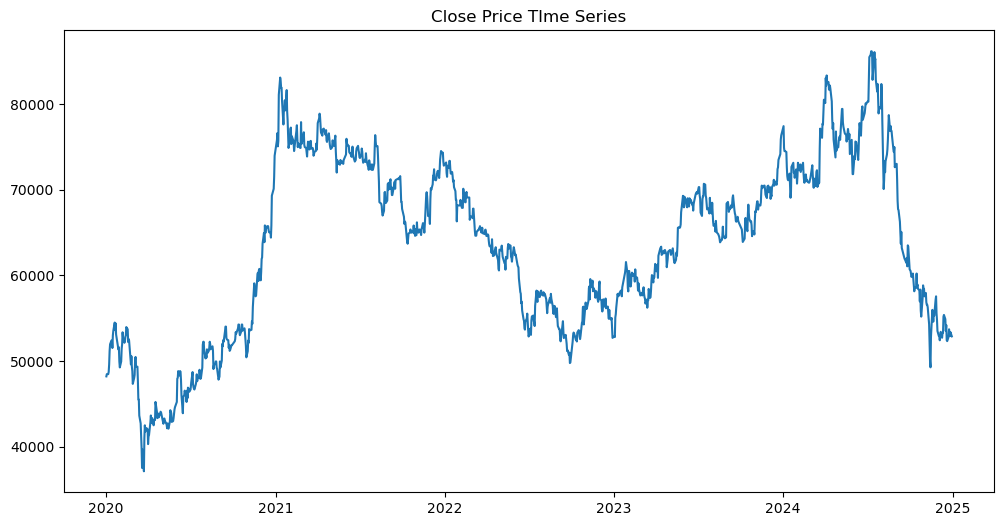

In [47]:
# Close 가격만 사용
ts = df['Close']

# 시계열 플롯
plt.figure(figsize=(12, 6))
plt.plot(ts)
plt.title('Close Price TIme Series')
plt.show()

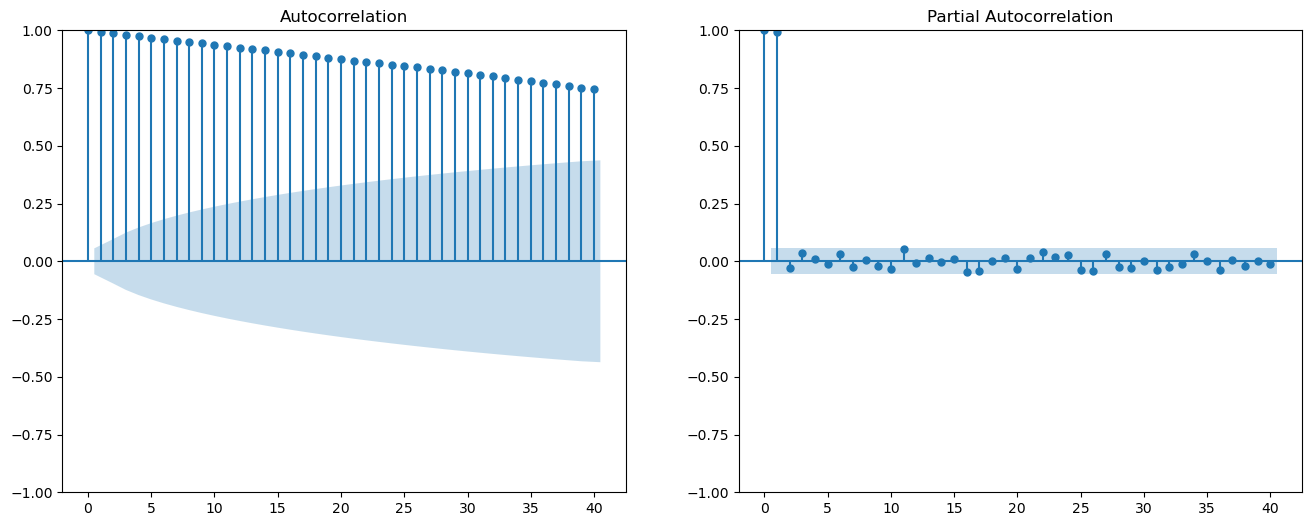

'\nACF : 과거 데이터와의 직접적인 상관 관계를 보여주며,\n시계열 데이터의 전반적인 패턴(추세, 계절성)을 파악하는 데 유용함\n\nPACF : 중간 시차의 영향을 제거한 순수한 상관 관계를 보여주며, \n시계열 모델의 AR 부분 차수를 결정하는 데 주로 사용함\n'

In [48]:
# 자기 상관 함수 (ACF) 및 편 자기 상관 함수 (PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# matplotlib.pyplot을 사용하여 1행 2열의 서브플롯을 생성
# fig는 전체 그림 객체를, axes는 각 서브플롯(그래프)에 대한 Axes 객체의 배열을 반환
# figsize는 그림의 전체 크기를 가로 16인치, 세로 6인치로 설정

plot_acf(ts, lags=40, ax=axes[0]) # 40일치 lag
# 첫 번째 서브플롯(axes[0])에 ts 시계열 데이터의 ACF를 그림
# lags=40은 최대 40개의 시차를 고려하여 계산

plot_pacf(ts, lags=40, ax=axes[1])
# 두 번째 서브플롯(axes[1])에 ts 시계열 데이터의 PACF를 그림
# lags=40은 최대 40개의 시차를 고려하여 계산

plt.show()

'''
ACF : 과거 데이터와의 직접적인 상관 관계를 보여주며,
시계열 데이터의 전반적인 패턴(추세, 계절성)을 파악하는 데 유용함

PACF : 중간 시차의 영향을 제거한 순수한 상관 관계를 보여주며, 
시계열 모델의 AR 부분 차수를 결정하는 데 주로 사용함
'''

In [49]:
# ADF 테스트 (정상성 확인)
# 비정상성 의심 -> 이러한 의심을 통계적으로 검증하는 방법
from statsmodels.tsa.stattools import adfuller

# 함수에 정상성 여부를 테스트할 시계열 데이터를 인자로 전달
# ts.dropna()는 ts 데이터에 혹시라도 존재하는 결측값을 제거하는 과정
# adfuller()는 결측값이 없는 데이터를 필요하므로, 안전한 테스트 수행하기 위해 결측값 제거
result = adfuller(ts.dropna()) 

# 튜플 형태로 결과 반환
# 검정 통계량 : 주어진 시계열 데이터가 단위근(시계열이 비정상을 띠는 주요 원인 중 하나)을 가지고 있는지 여부 판단
print('ADF Statistic:', result[0]) 
# p-값 : 통계적 가설 검정 핵심적인 값
print('p-value', result[1])
# 유의 수준(1%, 5%, 10%)에 대한 임계값을 딕셔너리 형태로 반환
# 임계값들은 계산된 ADF 통계량과 비교하여 귀무가설을 기각할지 말지 결정하는 데 사용
print('Critical Values:', result[4])

ADF Statistic: -1.9208673368979863
p-value 0.3223090246468565
Critical Values: {'1%': -3.4356950607889254, '5%': -2.863900342696613, '10%': -2.568026681232353}


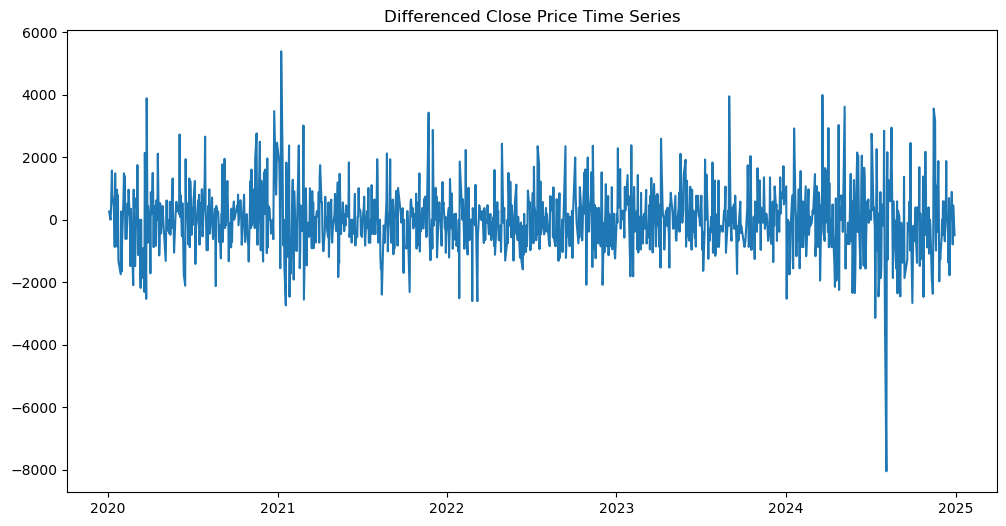

In [50]:
# p-value가 0.05보다 훨씬 크므로 정상성 만족 못함
# 정상성 만족하기 못할 경우, 차분 수행
ts_diff = ts.diff().dropna()

plt.figure(figsize=(12, 6))
plt.plot(ts_diff)
plt.title('Differenced Close Price Time Series')
plt.show()

In [51]:
# 차분된 데이터에 대한 ADF 테스트 재실행
result = adfuller(ts_diff) 

print('ADF Statistic:', result[0]) 
print('p-value', result[1])
print('Critical Values:', result[4])

ADF Statistic: -25.642118962351947
p-value 0.0
Critical Values: {'1%': -3.4356950607889254, '5%': -2.863900342696613, '10%': -2.568026681232353}


In [52]:
# 학습/검증/테스트 세트 분리
train_size = int(len(df) * 0.8)
val_size = int(len(df) * 0.1)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size : train_size + val_size]
test_df = df.iloc[train_size + val_size : ]

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 983
Validation set size: 122
Test set size: 124


In [53]:
# ARIMA 모델 학습
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# ARIMA 모델 파라미터 (p, d, q) 선택 - ACF, PACF, ADF 테스트 결과 기반으로 추정
# (p, d, q)는 AutoRegressive(AR), Integrated(I), MovingAverage(MA)의 차수를 의미
# 초보자 단계에서는 auto_arima를 사용하거나, 기본적인 값으로 시작 후 튜닝
# d=1은 1차 차분했음을 의미
order = (5, 1, 0) # 예시 값 (ACF/PACF 차트와 ADF 테스트 결과에 따라 변경 필요)

In [54]:
# 모델 학습 (학습 데이터 사용)
# df_train의 'Close'의 Series를 모델 학습에 사용
model_arima = ARIMA(train_df['Close'], order = order)
model_arima_fit = model_arima.fit()

model_arima_fit.summary()

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              005930.KS   No. Observations:                  983
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8110.874
Date:                Fri, 06 Jun 2025   AIC                          16233.749
Time:                        14:30:14   BIC                          16263.086
Sample:                             0   HQIC                         16244.909
                                - 983                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0174      0.027      0.651      0.515      -0.035       0.070
ar.L2         -0.0218      0.028     -0.781      0.435      -0.077       0.033
ar.L3          0.0115      0.030      0.376      0.707      -0.048       0.071
ar.L4          0.0109      0.028      0.386      0.700      -0.045       0.066
ar.L5         -0.0053      0.018     -0.289      0.772      -0.041       0.030
sigma2      8.732e+05   2.77e+04     31.573      0.000    8.19e+05    9.27e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               229.59
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                             0.58
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [55]:
# 에측 (검증 데이터에 대해)
# start와 end 인덱스를 사용하여 예측 범위 지정
start_index = len(train_df)
end_index = len(train_df) + len(val_df) - 1

# `dynamic=False`는 한 단계 앞 예측을 위해 실제 관측 값을 사용함을 의미
# `dynamic=True`는 이전 예측 값을 사용하여 다음 단계 예측을 수행함을 의미 (더 현실적인 미래 예측)
predictions_arima = model_arima_fit.predict(start=start_index, end=end_index, typ='levels')

# Series 형태로 예측값을 얻기 위해 인덱스를 맞춤
predictions_arima.index = val_df.index

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


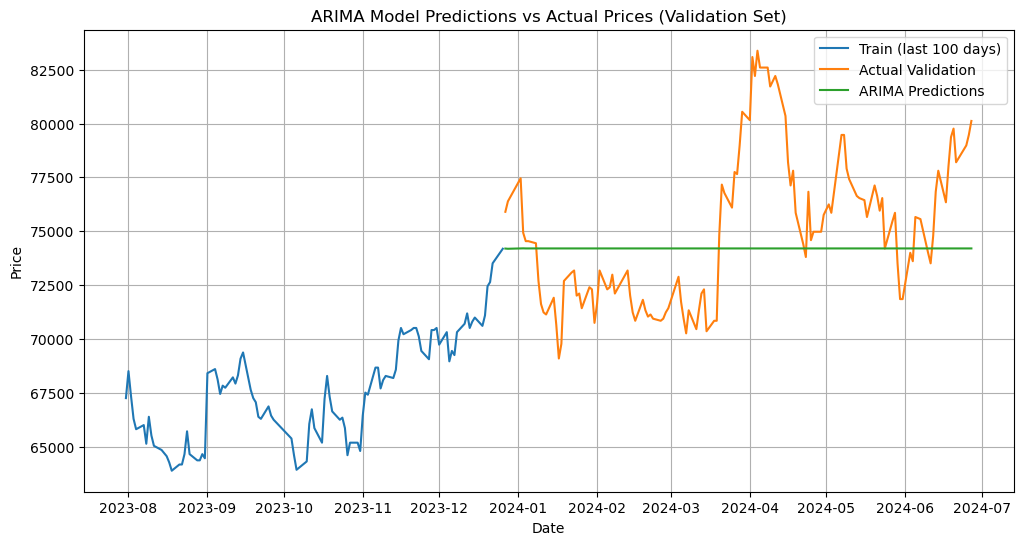

'\n- 파란색 선: 학습 데이터의 마지막 100일치를 보여준다.\n모델이 어떤 데이터를 보고 학습했는지 알 수 있음\n- 주황색 선: 검증 세트의 실제 종가이다. 모델이 예측해야 할 실제 값이다.\n- 초록색 선: ARIMA 모델이 예측한 종가이다.\n\n문제점\n초록색 선이 주황색 선을 전혀 따라가지 못하고 거의 일직선으로 수평하게 예측하고 있다.\n'

In [56]:
# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(train_df['Close'].iloc[-100:], label='Train (last 100 days)') # 학습 데이터의 마지막 부분
plt.plot(val_df['Close'], label='Actual Validation')
plt.plot(predictions_arima, label='ARIMA Predictions')
plt.title('ARIMA Model Predictions vs Actual Prices (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

'''
- 파란색 선: 학습 데이터의 마지막 100일치를 보여준다.
모델이 어떤 데이터를 보고 학습했는지 알 수 있음
- 주황색 선: 검증 세트의 실제 종가이다. 모델이 예측해야 할 실제 값이다.
- 초록색 선: ARIMA 모델이 예측한 종가이다.

문제점
초록색 선이 주황색 선을 전혀 따라가지 못하고 거의 일직선으로 수평하게 예측하고 있다.
'''

In [57]:
# 예측 성능 평가
rmse_arima = np.sqrt(mean_squared_error(val_df['Close'], predictions_arima))
print(f'ARIMA RMSE (Validation Set): {rmse_arima}')
'''
RMSE 값: 3549.10은 모델 예측 오차를 나타냄
주가 범위가 65000 ~ 82500 사이로 보이는데, 그에 비해 3500 이상의 RSME는 상당히 큰 오차이다.
'''

ARIMA RMSE (Validation Set): 3549.0998969091506


'\nRMSE 값: 3549.10은 모델 예측 오차를 나타냄\n주가 범위가 65000 ~ 82500 사이로 보이는데, 그에 비해 3500 이상의 RSME는 상당히 큰 오차이다.\n'

Epoch 1/20


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1230 - val_loss: 0.0047
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0083 - val_loss: 0.0041
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0047 - val_loss: 0.0053
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0044 - val_loss: 0.0031
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0046 - val_loss: 0.0030
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0043 - val_loss: 0.0028
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0039 - val_loss: 0.0027
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0040 - val_loss: 0.0033
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0040 - val_l

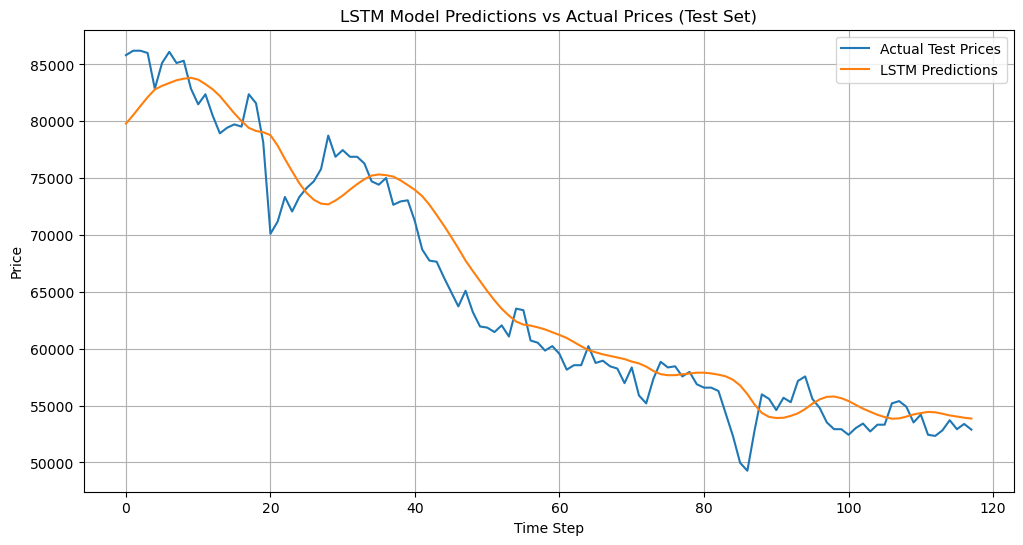

LSTM RMSE (Test Set): 2765.5462820481575


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# 데이터 스케일링 (LSTM은 스케일링에 민감)
# 0과 1 사이의 값으로 정규화하여 MinMaxScaler 객체 생성
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# 시퀀스 데이터 생성 함수
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

sequence_length = 60 # 60일치 데이터를 보고 다음 날 예측
X, y = create_sequences(scaled_data, sequence_length)

# 데이터셋 분리 (시계열 데이터는 시간 순서대로 분리)
train_size_scaled = int(len(X) * 0.8)
val_size_scaled = int(len(X) * 0.1)

X_train, y_train = X[:train_size_scaled], y[:train_size_scaled]
X_val, y_val = X[train_size_scaled : train_size_scaled + val_size_scaled], y[train_size_scaled : train_size_scaled + val_size_scaled]
X_test, y_test = X[train_size_scaled + val_size_scaled :], y[train_size_scaled + val_size_scaled :]

# LSTM 입력 형태 맞추기: (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# LSTM 모델 구축
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 모델 학습
history = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

# 예측 (테스트 데이터에 대해)
predictions_lstm_scaled = model_lstm.predict(X_test)
predictions_lstm = scaler.inverse_transform(predictions_lstm_scaled) # 원래 스케일로 복원

# 실제 값 (테스트 세트)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Test Prices')
plt.plot(predictions_lstm, label='LSTM Predictions')
plt.title('LSTM Model Predictions vs Actual Prices (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# 예측 성능 평가
rmse_lstm = np.sqrt(mean_squared_error(actual_prices, predictions_lstm))
print(f'LSTM RMSE (Test Set): {rmse_lstm}')